In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import os
from torch.utils.data import Dataset, DataLoader
import seaborn as sns
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import random
import csv
import json
from tqdm import tqdm
from joblib import Parallel, delayed
import IPython.display as ipd
import wandb
import re


import matplotlib.pyplot as plt
import seaborn as sns
import re
import wandb

/usr/lib/python3/dist-packages/requests/__init__.py:87: RequestsDependencyWarning: urllib3 (2.3.0) or chardet (4.0.0) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "


In [2]:
class CNNChromagram(nn.Module):
    def __init__(self, input_time=861):
        super(CNNChromagram, self).__init__()

        self.conv1 = nn.Conv2d(1, 32, kernel_size=(3, 3), padding='same', dilation=(1, 2))
        self.conv2 = nn.Conv2d(32, 64, kernel_size=(3, 3), padding='same', dilation=(1, 2))
        self.conv3 = nn.Conv2d(64, 128, kernel_size=(3, 3), padding='same', dilation=(1, 2))

        self.bn1 = nn.BatchNorm2d(32)
        self.bn2 = nn.BatchNorm2d(64)
        self.bn3 = nn.BatchNorm2d(128)

        fc_input_size = 64 * (25 // 4)

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=(2, 1))

        self.lstm = nn.LSTM(input_size=fc_input_size, hidden_size=128,
                            num_layers=1, batch_first=True, bidirectional=True)

        fc_input_size = 64 * (25 // 4)

        #self.fc1 = nn.Linear(fc_input_size, 64)
        self.fc1 = nn.Linear(128 * 2, 64)
        self.fc2 = nn.Linear(64, 5)

        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.pool(x)

        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool(x)

        x = self.relu(self.bn3(self.conv3(x)))
        x = self.pool(x)

        batch_size, channels, freq_bins, time_steps = x.shape

        x = x.permute(0, 3, 1, 2)
        x = x.reshape(batch_size, time_steps, -1)
        x, _ = self.lstm(x)
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

In [3]:
class ChromaDataset(Dataset):
    def __init__(self, audio_dir, label_json, num_classes=5, sr=16000, window_size=20, hop_length=512, target_bins=25):
        super().__init__()
        self.sr = sr
        self.target_bins = target_bins
        self.audio_files = [f for f in os.listdir(audio_dir) if f.endswith('.wav') or f.endswith('.mp3')]
        self.loaded_audio = self.get_audio(audio_dir)
        self.loaded_chromas = self.get_chroma()
        self.df = self.get_df(label_json)
        self.window_size = window_size
        self.window_frames = window_size*sr//hop_length
        self.num_classes = num_classes
        self.label_map = {"Unknown":0, "창조":0, "설렁제":0, "경드름": 0, "우조": 1, "계면조": 2, "평조": 3, "아니리": 4}
        self.hop_length = hop_length
        self.validation_index = {filename: 0 for filename in self.audio_files}

    def get_audio(self, audio_dir):
        '''
        오디오 파일을 load 후 Dictionary {filename: waveform} 형태로 저장
        '''
        loaded_audio = {}
        for filename in tqdm(self.audio_files, desc='Load Audio'):
            y, _ = librosa.load(os.path.join(audio_dir, filename), sr=self.sr)
            loaded_audio[filename] = y
        return loaded_audio

    def get_chroma(self):
        '''
        loaded_audio를 로드하여 file별로 chromagram 생성 후 target bins에 맞추어 expand하여 반환
        '''
        chroma_dict = {}
        for filename, audio_key_value in zip(tqdm(self.audio_files, desc="Load Chroma"), self.loaded_audio.items()):
            chroma = librosa.feature.chroma_stft(y=audio_key_value[1], sr=self.sr)
            repeat = self.target_bins // chroma.shape[0] + 1
            expanded_chroma = np.tile(chroma, (repeat, 1))
            chroma_dict[filename]=expanded_chroma[:self.target_bins, :]
        return chroma_dict

    def get_df(self, label_json):
        with open(label_json, "r", encoding="utf-8") as file: label_data = json.load(file)
        df = pd.DataFrame(columns=['filename', 'start', 'end', 'duration', 'label'])
        row = 0

        # 노래 파일 마다 레이블 정보 저장
        song_segments = {}
        for song in label_data:
            filename = song['file_upload'][:-3]+'wav'
            if filename not in song_segments: song_segments[filename] = []

            for val in song['annotations'][0]["result"]:
                start = val['value']['start']
                end = val['value']['end']
                label = val['value']['labels'][0]
                song_segments[filename].append((start, end, label))

        for filename, segments in song_segments.items():
            prev_end = None
            segments.sort(key=lambda x: x[0])
            for start, end, label in segments:
                if prev_end is not None and int(prev_end) != int(start):
                    gap_start, gap_end = prev_end+1e-6, start-1e-6
                    gap_duration = gap_end - gap_start

                    if gap_duration < 1: continue
                    df.loc[row] = [filename, gap_start, gap_end, gap_duration, "Unknown"]
                    row += 1

                duration = end - start
                df.loc[row] = [filename, start, end, duration, label]
                prev_end = end
                row += 1
        return df

    def get_label_for_segment(self, filename, start_frame, end_frame):
        segment_labels = np.zeros((self.window_frames, self.num_classes))
        segment_labels[:, self.label_map["Unknown"]] = 1

        file_df = self.df[self.df['filename'] == filename]

        if not file_df.empty:
            for _, row in file_df.iterrows():
                label_start_frame = int((row['start'] / self.hop_length) * self.sr)
                label_end_frame = int((row['end'] / self.hop_length) * self.sr)

                overlap_start = max(start_frame, label_start_frame)
                overlap_end = min(end_frame, label_end_frame)

                if overlap_start < overlap_end:
                    segment_start_idx = int(overlap_start - start_frame)
                    segment_end_idx = int(overlap_end - start_frame)

                    segment_labels[segment_start_idx:segment_end_idx, self.label_map["Unknown"]] = 0
                    label_idx = self.label_map.get(row['label'], self.label_map["Unknown"])
                    segment_labels[segment_start_idx:segment_end_idx, label_idx] = 1

        return torch.tensor(segment_labels, dtype=torch.float32)

    def shift_chroma(self, chroma, max_shift = 4, prob = 0.4):
        if random.random() < prob:
            shift = random.randint(-max_shift, max_shift)
            chroma = np.roll(chroma, shift, axis = 0)
        return chroma

    def __getitem__(self, args):

        if isinstance(args, tuple):
            idx, mode = args

        else:
            idx, mode = args, 'train'

        filename = self.audio_files[idx % len(self.audio_files)]
        duration = librosa.get_duration(y=self.loaded_audio[filename], sr=self.sr)
        num_frames = self.loaded_chromas[filename].shape[1]

        if mode == 'train':
            # 첫 번째 segment는 0에서 시작, 이후 랜덤 샘플링
            if duration < self.window_size:
                start_time = 0
            else:
                start_time = random.uniform(0, max(1, duration - self.window_size))

        elif mode == 'validation':
            start_time = self.validation_index[filename]
            if start_time + self.window_size < duration:
                self.validation_index[filename] += 20
            else:
                self.validation_index[filename] = 0

        start_frame = int(num_frames * start_time / duration)
        end_frame = int(start_frame + self.window_frames)
        chroma = self.loaded_chromas[filename][:, start_frame:end_frame]
        chroma = self.shift_chroma(chroma)
        label = self.get_label_for_segment(filename, start_frame, end_frame)

        return chroma, label, duration, (filename, start_frame, end_frame)

In [4]:
wandb.init(project="Real Mode Detection", name="LOO_5", config={"epochs": 70})
wandb.define_metric("Train Loss", step_metric="epoch")
wandb.define_metric("Train Accuracy", step_metric="epoch")
wandb.define_metric("Validation Loss", step_metric="epoch")
wandb.define_metric("Validation Accuracy", step_metric="epoch")

audio_dir = '/home/sangheon/Desktop/Pansori/Audio'
label_dir = '/home/sangheon/Desktop/Pansori_2025_ISMIR/data/label.json'

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dataset = ChromaDataset(audio_dir, label_dir)
song_files = dataset.audio_files
loo = LeaveOneOut()
loo_losses = []
loo_accs = []
frame_accs = []
batch_size = 8

for fold_idx, (train_idx, test_idx) in enumerate(loo.split(song_files)):
    model = CNNChromagram().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    wandb.init(
        project="Real Mode Detection",
        name=f"LeaveOneOut_Training_Fold_{fold_idx}",
        reinit=True,
        config={"epochs": 100}
    )

    for epoch in range(101):
        model.train()
        total_loss = 0
        correct_train, total_train = 0, 0

        train_X, train_y = [], []

        for idx in train_idx:
            _, _, duration, (_, _, _) = dataset[idx]
            num_segments = int(duration // 20)
            for segment in range(num_segments):
                chroma, label, duration, (filename, start, end) = dataset[(idx, 'train')]
                chroma = torch.tensor(chroma, dtype=torch.float32).unsqueeze(0)
                label = torch.tensor(label, dtype=torch.float32)
                train_X.append(chroma)
                train_y.append(label)

        train_X = torch.stack(train_X).to(device)
        train_y = torch.stack(train_y).to(device).argmax(dim=-1)

        for i in range(0, len(train_X), batch_size):
            batch_X = train_X[i:i+batch_size]
            batch_y = train_y[i:i+batch_size]
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs.permute(0, 2, 1), batch_y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

            pred_train = torch.argmax(outputs, dim=-1)
            correct_train += (pred_train == batch_y).sum().item()
            total_train += batch_y.numel()

        train_loss = total_loss / len(train_X)
        train_acc = correct_train / total_train
        wandb.log({
                    "Train Loss": train_loss,
                    "Train Accuracy": train_acc,
                    "epoch": epoch
                    })

        if epoch % 10 == 0:

            model.eval()

            with torch.no_grad():
                val_X, val_y = [], []
                max_len = 0
                _, _, duration, (val_file, _, _) = dataset[int(test_idx[0])]
                num_segments = int(duration // 20)

                for segment in range(num_segments):
                    chroma, label, duration, (filename, start, end) = dataset[(int(test_idx[0]), 'validation')]
                    chroma = torch.tensor(chroma, dtype=torch.float32).unsqueeze(0)
                    label = torch.tensor(label, dtype=torch.float32)

                    val_X.append(chroma)
                    val_y.append(label)

                    max_len = max(max_len, chroma.shape[-1])

                val_X = [F.pad(x, (0, max_len - x.shape[-1])) for x in val_X]
                val_X = torch.stack(val_X).to(device)
                val_y = torch.stack(val_y).to(device).argmax(dim=-1)

                val_output = model(val_X)
                val_loss = criterion(val_output.permute(0, 2, 1), val_y)

                pred_probs = torch.softmax(val_output, dim=-1)
                pred_labels = torch.argmax(pred_probs, dim=-1)
                frame_accuracy = (pred_labels == val_y).float().mean(dim=1).cpu().numpy()
                accuracy = frame_accuracy.mean().item()

                wandb.log({
                    "Validation Loss": val_loss.item(),
                    "Validation Accuracy": accuracy,
                    "epoch": epoch
                    }, commit = False)

    loo_losses.append(val_loss.item())
    loo_accs.append(accuracy)

    print(f"Val_Filename: {filename}")
    print(f"accuracy: {accuracy}")

    val_y = val_y.cpu().numpy().ravel()
    pred_labels = pred_labels.cpu().numpy().ravel()
    hash_value = re.match(r"^[a-zA-Z0-9\-]+", filename).group()

    cm = confusion_matrix(val_y, pred_labels, labels=[0, 1, 2, 3, 4], normalize="true")
    plt.figure(figsize=(8, 8))
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=[0, 1, 2, 3, 4], yticklabels=[0, 1, 2, 3, 4])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix for Validation: {hash_value}")
    plt.savefig(f'Confusion_matrix_fold_{fold_idx}.png')
    plt.close()
    wandb.log({f"Confusion Matrix Fold {fold_idx}": wandb.Image(f'Confusion_matrix_fold_{fold_idx}.png')})
    wandb.finish()

print("\n LOO-CV Results")
print(f"Average Validation Loss: {np.mean(loo_losses):.4f}")
print(f"Average Validation Accuracy: {np.mean(loo_accs):.4f}")

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: michpark (michpark-georgia-institute-of-technology) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Load Chroma: 100%|██████████| 18/18 [00:07<00:00,  2.31it/s]


/tmp/ipykernel_1066477/1046862725.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label = torch.tensor(label, dtype=torch.float32)
/tmp/ipykernel_1066477/1046862725.py:87: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label = torch.tensor(label, dtype=torch.float32)


Val_Filename: c9f91d52-03-김수연-심청가_범피중류.wav
accuracy: 0.2102518379688263


Train Accuracy,▁▂▃▃▃▄▅▄▅▅▆▆▅▅▆▆▆▆▅▆▆▆▅▆▆▆▆▅▆▆▆▆▆▆▅▇▇▇██
Train Loss,█▇▇▆▆▅▆▅▅▅▅▄▄▄▄▄▃▄▃▄▃▄▃▃▃▃▃▃▃▃▂▃▂▂▃▂▂▂▂▁
Validation Accuracy,▁▁▁▂▁▂▂▂▂█▄
Validation Loss,█▄▆▅▃▁▃▃▄▁▅
epoch,▁▁▂▂▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇██
Train Accuracy,0.50143
Train Loss,0.12767
Validation Accuracy,0.21025
Validation Loss,1.29512
epoch,100


...

Train Accuracy,▁▁▂▂▂▂▄▄▄▄▅▄▅▄▅▄▆▆▄▆▆▆▆▅▅▅▅▆▆▆▆▆▆▆▆▆▄▆▇█
Train Loss,█▆▆▆▆▅▄▄▄▄▅▃▃▄▃▃▃▃▃▃▃▃▂▂▂▃▂▂▂▃▂▂▁▂▂▂▂▁▂▁
Validation Accuracy,▂▃▃▃▅▁▂█▇█▇
Validation Loss,▅▄▇▅▂█▆▁▂▃▁
epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇██
Train Accuracy,0.45571
Train Loss,0.14118
Validation Accuracy,0.384
Validation Loss,1.18302
epoch,100


/tmp/ipykernel_1066477/1046862725.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label = torch.tensor(label, dtype=torch.float32)
/tmp/ipykernel_1066477/1046862725.py:87: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  label = torch.tensor(label, dtype=torch.float32)


Val_Filename: 30c011be-01-박초월-수궁가_별주부_토끼_유인하는_대목.wav
accuracy: 0.4089599847793579


Train Accuracy,▂▂▂▂▂▂▁▂▂▄▆▆▆▄▆▆▆▆▇▇▅▆▅▇▃▇▇▆▆▆▅▅▄▆█▇██▆▇
Train Loss,██▇█▇▇█▇▇█▄▄▃▄▃▃▂▄▃▃▂▂▃▃▃▂▃▂▂▁▂▂▁▂▂▁▂▂▁▁
Validation Accuracy,▁▆▅▄█▇██▆▆█
Validation Loss,█▇▄▃▃▂▁▁▂▂▂
epoch,▁▁▁▁▁▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇▇██
Train Accuracy,0.40023
Train Loss,0.15185
Validation Accuracy,0.40896
Validation Loss,1.14424
epoch,100



 LOO-CV Results
Average Validation Loss: 1.3438
Average Validation Accuracy: 0.2984


# Test Script 

In [ ]:
audio_dir = '/home/sangheon/Desktop/Pansori/Audio'
label_dir = '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/label.json'

dset = ChromaDataset(audio_dir, label_dir)

chroma, label, duration, (filename, start, end) = dset[18]
print(f"Filename: {filename}")
print(f"Start Frame: {start}, End Frame: {end}")
print(f"Duration {duration}")
print(f"Chroma Shape: {chroma.shape}")

plt.subplot(2, 1, 1)
plt.imshow(chroma, aspect = 'auto', origin ='lower')

#plt.imshow(dset.loaded_chromas[filename][:,start:end], aspect = 'auto', origin ='lower')

plt.subplot(2,1,2)
plt.imshow(label, aspect='auto', interpolation='None')

s_t = start*512
e_t = end*512

ipd.display(ipd.Audio(data=dset.loaded_audio[filename][s_t:e_t], rate=16000))
print(s_t/16000, e_t/16000)

Load Chroma: 100%|██████████| 18/18 [00:07<00:00,  2.29it/s]


Chroma Shape: (25, 625)
Shifted Chroma Shape: (25, 625)


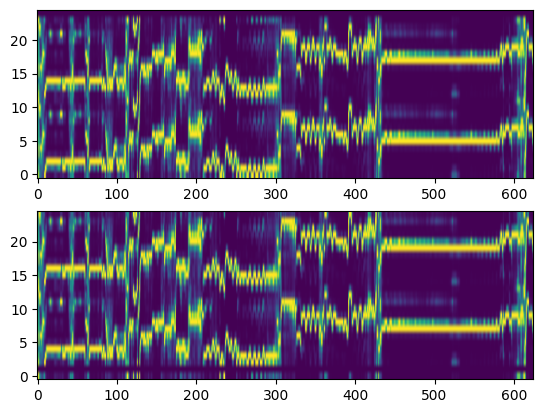

In [6]:
audio_dir = '/home/sangheon/Desktop/Pansori/Audio'
label_dir = '/home/sangheon/Desktop/Pansori_2025_ISMIR/data/label.json'

dset = ChromaDataset(audio_dir, label_dir)

chroma, label, duration, (filename, start, end) = dset[18]

plt.subplot(2, 1 ,1)
plt.imshow(chroma, aspect = 'auto', origin = 'lower')
print(f'Chroma Shape: {chroma.shape}')
shift = random.randint(-3, 3)
chroma = np.roll(chroma, shift, axis = 0)

plt.subplot(2, 1, 2)
plt.imshow(chroma, aspect = 'auto', origin = 'lower')
print(f'Shifted Chroma Shape: {chroma.shape}')